In [2]:
import sklearn
print (sklearn.__version__)

1.6.1


In [3]:
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()

# Convert to DataFrame
import pandas as pd
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # Add target column

# Display first few rows
print(df.head())


   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

### Data Preparation

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [5]:
# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target


In [6]:
# Check for missing values
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [8]:
# Split dataset into features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Standardization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



## Step 3: Feature Selection

In [9]:
# Import Necessary Libraries
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, f_classif

In [10]:
# Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # Add target column

# Separate features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']


In [11]:
# Select top K features
k = 10  # Choose the number of best features
selector = SelectKBest(score_func=f_classif, k=k)
X_new = selector.fit_transform(X, y)

# Get selected feature names
selected_features = X.columns[selector.get_support()]

# Print selected features
print("Selected Features:")
print(selected_features)


Selected Features:
Index(['mean radius', 'mean perimeter', 'mean area', 'mean concavity',
       'mean concave points', 'worst radius', 'worst perimeter', 'worst area',
       'worst concavity', 'worst concave points'],
      dtype='object')


In [12]:
#Use Selected Features for Model Training

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Keep only selected features
X_selected = df[selected_features]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Normalize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



## Step 4: Grid Search CV for Model Tuning

In [13]:
#import libraries

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

In [14]:
# Select the top features (replace with your selected features from Step 3)
selected_features = [
    'mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness',
    'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area'
]
X = df[selected_features]  # Use only selected features
y = df['target']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
# Define MLPClassifier model
mlp = MLPClassifier(max_iter=500, random_state=42)

# Define parameter grid for tuning
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],  # Number of neurons in layers
    'activation': ['relu', 'tanh'],  # Activation function
    'solver': ['adam', 'sgd'],  # Optimizer
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization
    'learning_rate': ['constant', 'adaptive']  # Learning rate
}

### Perform Grid Search Cross-Validation

In [17]:
# Set up GridSearchCV
grid_search = GridSearchCV(mlp, param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit model to training data
grid_search.fit(X_train, y_train)

# Get best parameters
print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50,), 'learning_rate': 'constant', 'solver': 'adam'}


In [18]:
# Get the best model
best_model = grid_search.best_estimator_

# Test set accuracy
test_accuracy = best_model.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9386


## Steps to Create an ANN Model
1 . Load & preprocess the data
 - Use the best-selected features from Step 3
 - Split into training and test sets
 - Normalize the dataset

2 . Define the ANN architecture
 - Choose the number of neurons per layer
 - Select the activation function
 - Define the optimizer and learning rate

3 . Train the model
 - Fit the model on training data
 
4 . Evaluate the model
 - Measure accuracy and other performance metrics

In [19]:
#Import Required Libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


### Load and Preprocess the Dataset

In [20]:
# Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # Add target column

# Select the best features (from Step 3)
selected_features = [
    'mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness',
    'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area'
]
X = df[selected_features]  # Use only the selected features
y = df['target']

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the dataset
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [21]:
# Define the ANN model
model = MLPClassifier(
    hidden_layer_sizes=(100,),  # 1 hidden layer with 100 neurons
    activation='relu',          # ReLU activation function
    solver='adam',              # Adam optimizer
    alpha=0.001,                # L2 regularization
    learning_rate='adaptive',   # Adaptive learning rate
    max_iter=500,               # Number of epochs
    random_state=42
)


In [22]:
# Train the ANN model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)


c:\Users\OWNER\Desktop\CCBST Class\Breast_Cancer_Assignment\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Test Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



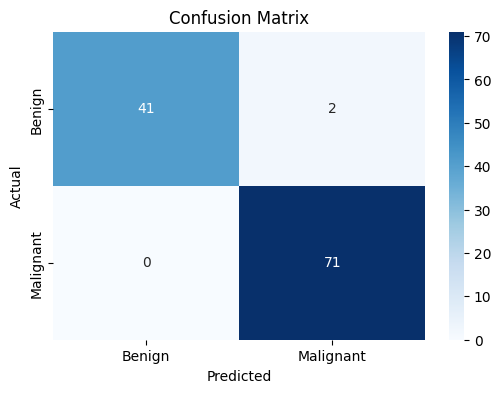

In [23]:
# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
